In [4]:
# Generiamo un data set sintetico con due cluster e circa il 10% di outlier

from sklearn.datasets import make_moons
import numpy as np

# numeri del data set
N = 1500
n_c1 = 543
n_c2 = 812
n_outlier = N - n_c1 - n_c2

# Creiamo i punti dei cluster
X_clusters, y_clusters = make_moons(n_samples=n_c1+n_c2, noise=0.05)

# Creiamo gli outlier
X_outlier = np.random.uniform(-2, 4, size=(n_outlier, 2))
y_outlier = -1 * np.ones(n_outlier, dtype=int)

# scaliamo e trasliamo i punti per adattarli meglio all'intervallo
X_clusters = 1.5 * X_clusters + np.array([0.7, 0.7])

# Facciamo lo stacking delle X e delle y per generare i dataset intero
X = np.vstack([X_clusters, X_outlier])
y = np.hstack([y_clusters, y_outlier])

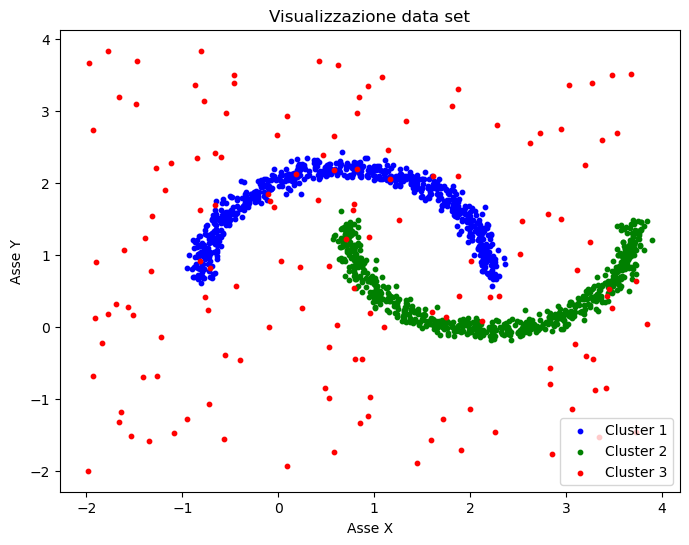

In [5]:
# Visualizziamo il data set
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Scatter dei punti
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='Cluster 1', s=10)
plt.scatter(X[y==1, 0], X[y==1, 1], c='green', label='Cluster 2', s=10)
plt.scatter(X[y==-1, 0], X[y==-1, 1], c='red', label='Cluster 3', s=10)

plt.title('Visualizzazione data set')
plt.xlabel('Asse X')
plt.ylabel('Asse Y')
plt.legend()

plt.show()

In [9]:
# Calcoliamo il LOF per diversi valori dei k-vicini

from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import accuracy_score

# Lista dei k-vicini investigati
k_vicini = [2, 5, 10, 20, 25, 30, 40, 50]

# Lista dei modelli e delle accuracy sulle etichette -1
modelli_lof = []
accuratezze = []

# Iteriamo sulla lista dei k_vicini
for k in k_vicini:
    
    # Calcolo del lof
    lof = LocalOutlierFactor(n_neighbors=k, novelty=False)
    
    # predizione degli outlier
    y_pred = lof.fit_predict(X)
    
    y_pred_binary = np.where(y_pred == -1, -1, 1)
    y_binary = np.where(y == -1, -1, 1)
    
    # Calcolo dell'accuratezza
    acc = accuracy_score(y_binary, y_pred_binary)
    
    # Aggiungiamo il modello e l'accuratezza alle rispettive liste
    accuratezze.append(acc)
    modelli_lof.append(lof)
    
    # Stampa del valore di accuratezza corrente
    print(f'Accuratezza per il modello che usa {k} vicini: {acc:5.4f}')

Accuratezza per il modello che usa 2 vicini: 0.8060
Accuratezza per il modello che usa 5 vicini: 0.9020
Accuratezza per il modello che usa 10 vicini: 0.9340
Accuratezza per il modello che usa 20 vicini: 0.9707
Accuratezza per il modello che usa 25 vicini: 0.9773
Accuratezza per il modello che usa 30 vicini: 0.9813
Accuratezza per il modello che usa 40 vicini: 0.9813
Accuratezza per il modello che usa 50 vicini: 0.9807


In [10]:
# Calcoliamo il risultato di DBSCAN con un insieme opportuno di iperparametri Eps, MinPts

from sklearn.cluster import DBSCAN
from sklearn.model_selection import ParameterGrid

# Griglia degli iperparametri
param_grid = {'eps': [0.05, 0.1, 0.2, 0.5], 'min_samples': [2, 5, 10, 20, 30]}

# Creiamo il nostro scorer personalizzato che attribuisce -1 agli outlier e 1 a tutti gli inlier
def accuracy_outlier(y_true, y_pred):
    
    y_pred_binary = np.where(y_pred == -1, -1, 1)
    y_true_binary = np.where(y_true == -1, -1, 1)
    
    return accuracy_score(y_true_binary, y_pred_binary)

# Salviamo in queste vartiabili il miglior modello e la migliore accuratezza
miglior_modello = None
miglior_accuratezza = 0

# Iteriamo sulla griglia di iperparametri
for params in ParameterGrid(param_grid):
    
    # creiamo l'ogetto dbscan
    dbscan = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    
    # Addestramento
    y_pred = dbscan.fit_predict(X)
    
    acc = accuracy_outlier(y, y_pred)
    
    if acc > miglior_accuratezza:
        
        miglior_accuratezza = acc
        miglior_modello = dbscan

# Stampiamo i risultati della ricerca
print(f'Miglior modello:\neps = {miglior_modello.eps}\nmin_samples = {miglior_modello.min_samples}')
print(f'Accuratezza del miglior modello sugli outlier: {miglior_accuratezza: 5.4f}')

Miglior modello:
eps = 0.2
min_samples = 30
Accuratezza del miglior modello sugli outlier:  0.9807


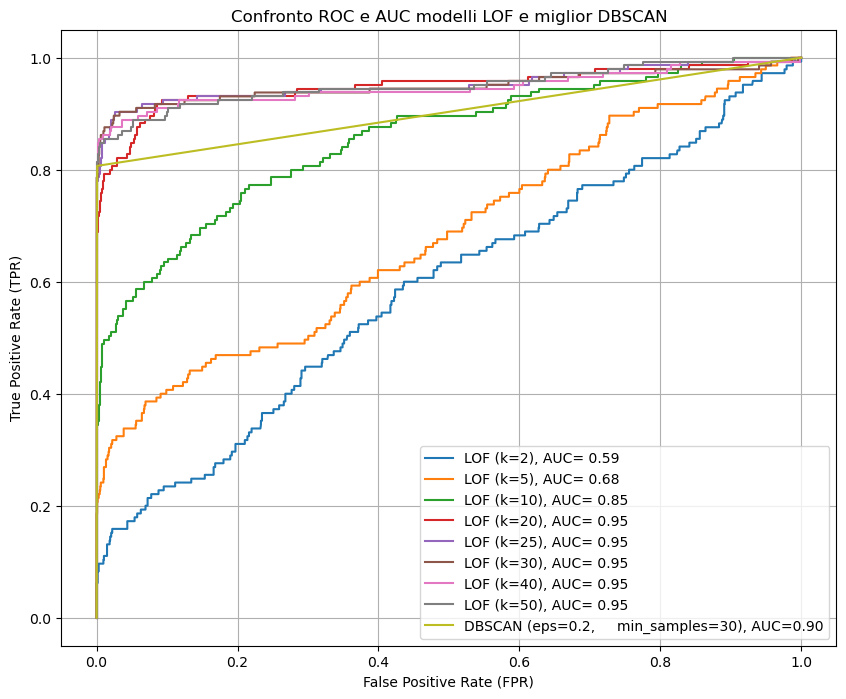

In [12]:
# Confrontiamo i modelli LOF e il miglior modello DBSCAN in termini della curva ROC e della AUC

from sklearn.metrics import roc_curve, auc

def calcola_roc_auc(y_true, y_scores):
    
    y_binary = np.where(y_true == -1, 1, 0)
    
    fpr, tpr, _ = roc_curve(y_binary, y_scores)
    
    roc_auc = auc(fpr, tpr)
    
    return fpr, tpr, roc_auc

plt.figure(figsize=(10, 8))

for i , lof in enumerate(modelli_lof):
    
    # Calcolo gli score del modello i-esimo
    y_scores = -lof.negative_outlier_factor_
    
    fpr, tpr, roc_auc = calcola_roc_auc(y, y_scores)
    
    plt.plot(fpr, tpr, label=f'LOF (k={k_vicini[i]}), AUC={roc_auc: 4.2f}')

# Eseguo la stessa procedura per il modello DBSCAN
y_scores_dbscan = np.where(miglior_modello.fit_predict(X) == -1, 1, 0)

fpr_dbscan, tpr_dbscan, roc_auc_dbscan = calcola_roc_auc(y, y_scores_dbscan)

plt.plot(fpr_dbscan, tpr_dbscan, label=f'DBSCAN (eps={miglior_modello.eps}, \
    min_samples={miglior_modello.min_samples}), AUC={roc_auc_dbscan:4.2f}')

plt.title('Confronto ROC e AUC modelli LOF e miglior DBSCAN')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()
